In [43]:
import os
if os.getcwd().endswith('scripts'):
    os.chdir('..')
print(f"Current working directory: {os.getcwd()}")

Current working directory: /data6/yuzihan/WorkSpace/35-HuaweiCrowdSimulation/HuaweiCrowdSimulationCode


Text(0.5, 0, '')

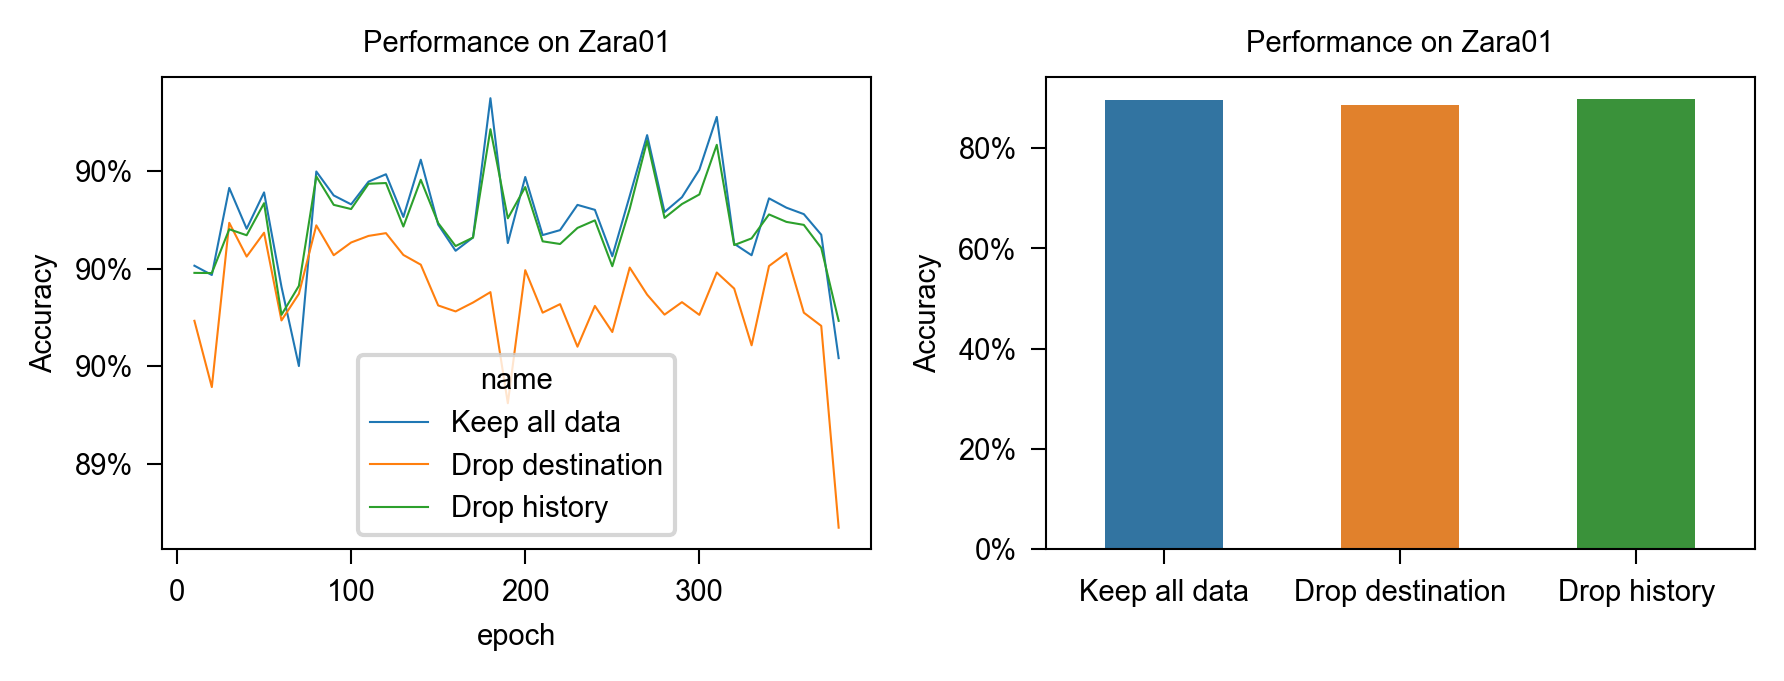

In [44]:
import numpy as np
import pandas as pd
from pathlib import Path
from src.utils.plot import get_fig, plt, sns

path = Path('logs/train/20251009_drop_des_or_hst_164920_DL4')

df = pd.read_json(path / 'records.jsonl', lines=True)
df = df[df['ade'].notna()]
df['Accuracy'] = 1 - df['ade'].apply(np.mean)  / df['trajlen'].apply(np.mean)
df.loc[df['drop_des'].notna(), 'name'] = 'Drop destination'
df.loc[df['drop_hst'].notna(), 'name'] = 'Drop history'
df.loc[df['drop_des'].isna() & df['drop_hst'].isna(), 'name'] = 'Keep all data'
# df_dropdes = df[df['drop_des'].notna()]
# df_drophst = df[df['drop_hst'].notna()]
# df_baseline = df[df['drop_des'].isna() & df['drop_hst'].isna()]

fi, fig, axes = get_fig(1, 2, AW=6, AH=4, dpi=300, HS=6)
ax = axes[0]
sns.lineplot(data=df, x='epoch', y='Accuracy', hue='name', ax=ax)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax.set_title('Performance on Zara01')

ax = axes[1]
df_last = df.sort_values('epoch').groupby('name').tail(1)
sns.barplot(data=df_last, x='name', hue='name', y='Accuracy', ax=ax, width=0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax.set_title('Performance on Zara01')
ax.set_xlabel('')

Text(0.5, 0, '')

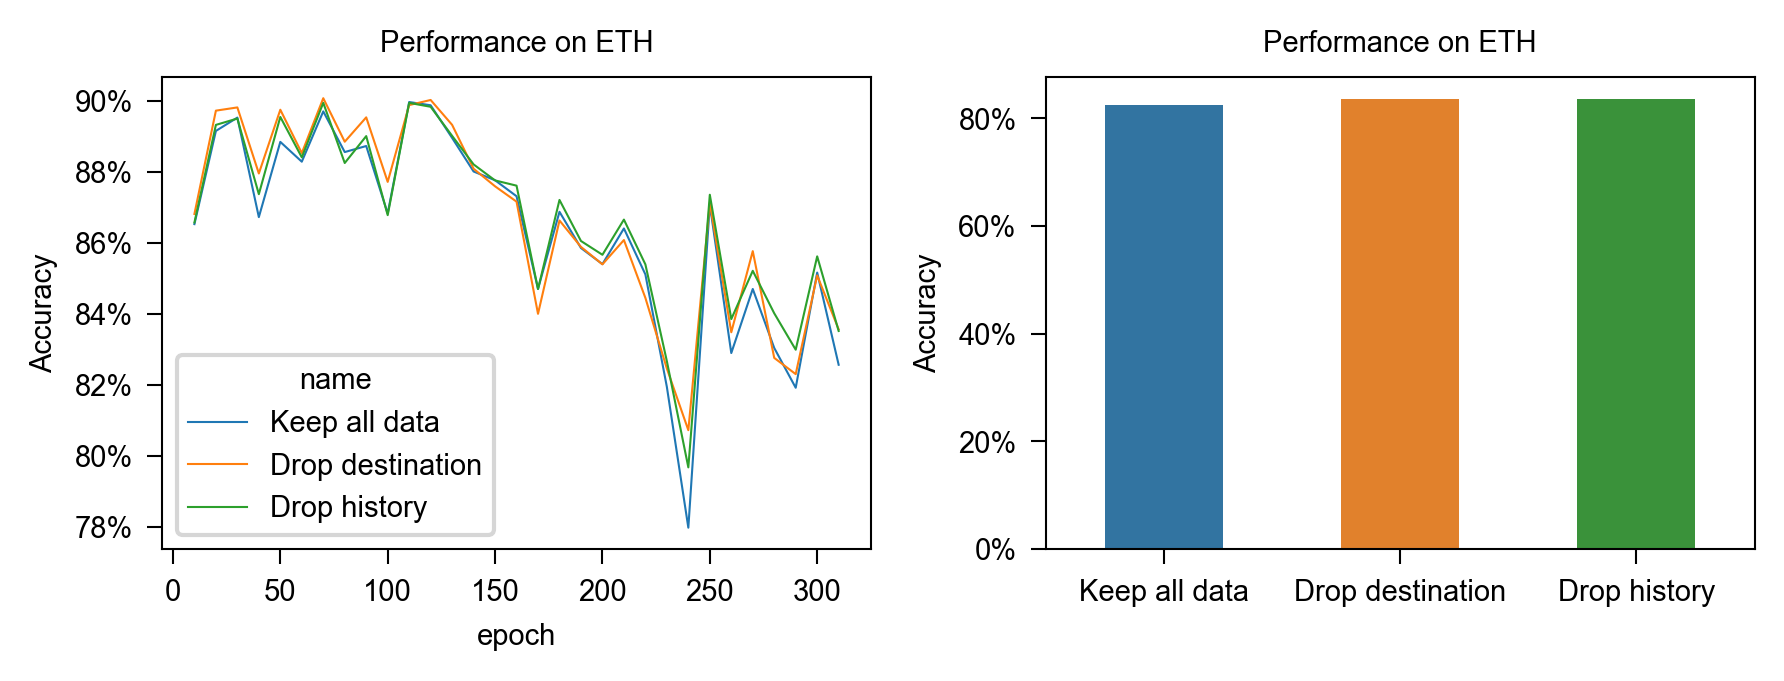

In [45]:
import numpy as np
import pandas as pd
from pathlib import Path
from src.utils.plot import get_fig, plt, sns

path = Path('logs/train/20251009_drop_des_or_hst_170355_DL4')

df = pd.read_json(path / 'records.jsonl', lines=True)
df = df[df['ade'].notna()]
df['Accuracy'] = 1 - df['ade'].apply(np.mean)  / df['trajlen'].apply(np.mean)
df.loc[df['drop_des'].notna(), 'name'] = 'Drop destination'
df.loc[df['drop_hst'].notna(), 'name'] = 'Drop history'
df.loc[df['drop_des'].isna() & df['drop_hst'].isna(), 'name'] = 'Keep all data'
# df_dropdes = df[df['drop_des'].notna()]
# df_drophst = df[df['drop_hst'].notna()]
# df_baseline = df[df['drop_des'].isna() & df['drop_hst'].isna()]

fi, fig, axes = get_fig(1, 2, AW=6, AH=4, dpi=300, HS=6)
ax = axes[0]
sns.lineplot(data=df, x='epoch', y='Accuracy', hue='name', ax=ax)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax.set_title('Performance on ETH')

ax = axes[1]
df_last = df.sort_values('epoch').groupby('name').tail(1)
sns.barplot(data=df_last, x='name', hue='name', y='Accuracy', ax=ax, width=0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
ax.set_title('Performance on ETH')
ax.set_xlabel('')